In [23]:

import nest_asyncio
nest_asyncio.apply()  # 중첩 이벤트 루프 허용
import os
import json
import logging
import asyncio
import pandas as pd
import numpy as np
import openai
from datetime import datetime
import sys
from typing import List, Dict, Optional
# from tenacity import retry, stop_after_attempt, wait_exponential
import re
import gc
from tqdm import tqdm
api = pd.read_csv('../../data/info.csv')
api_key = api.loc[1][1]


/var/folders/7z/944bgjcs659fsp58nc954qgm0000gn/T/ipykernel_15196/1504090882.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  api_key = api.loc[1][1]


In [24]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_colwidth', None)


In [25]:
sens = pd.read_parquet('/Users/nam-yeong/git/prj_centum/gpt_word/final_result/final_result_20250410_060315.parquet')
nums = pd.read_parquet('../../data/centum_data_numeric_cleaned.parquet')

sens['날짜'] = pd.to_datetime(sens['날짜'])
df = pd.merge(nums, sens, on=['환자번호','날짜'], how='left')

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
df = pd.merge(nums, sens, on=['환자번호','날짜'], how='left')
cols = [
       '환자번호', '날짜', 'CC', '약', '장치', '습관', '찜질', '마사지, 스트레칭', 'PI',
       'CMO', 'MMO', 'Cap.pal', 'M.pal', 'Noise', 'Loading',
       'Occlusion', 'OJ/OB', 'Class', 'Midline Shift', 'Deviation', 'CR-CO',
       'Tongue ridging', 'Mucosal ridging', 'Ultrasono', 'Rt', 'Lt', '치료계획',
       'End feel',
       'CC_location', 'CC_pain_type', 'CC_painUncomp_desc_jaw',
       'CC_disable_desc_jaw', 'CC_muscle_joint_desc_stress',
       'CC_dentalHistory_desc', 'CC_clinic_history_desc', 'CC_factor_habbit',
       'CC_treat_plan', 'CC_severity', 'CC_duration',
       '약_medication_type', '약_frequency', '약_duration', '약_compliance',
       '장치_device_type', '장치_usage_pattern', '장치_duration', '장치_compliance',
       '습관_habit_type', '습관_frequency', '습관_awareness', '습관_improvement',
       '찜질_status', '찜질_frequency', '찜질_duration', '찜질_method',
       '마사지, 스트레칭_type', '마사지, 스트레칭_frequency', '마사지, 스트레칭_duration',
       '마사지, 스트레칭_method',
       'CMO_before', 'CMO_after', 'MMO_before', 'MMO_after',
       'deviation_pattern_type', 'deviation_direction', 'deviation_intensity',
       'Cap.pal_Pain_Intensity', 'Cap.pal_Pain_Direction',
       'Cap.pal_Pain_Situation', 'M.pal_Pain_Intensity',
       'M.pal_Pain_Direction', 'M.pal_Pain_Situation', 'Noise_Code',
       'Noise_Direction', 'Noise_Intensity', 'Noise_Situation',
       'Occlusion_lt_number', 'Occlusion_rt_number', 'Occlusion_lt_Intensity',
       'Occlusion_rt_Intensity', 'oj', 'ob', 'Midline_Shift_Jaw',
       'Midline_Shift_Direction_x', 'Midline_Shift_Direction_y',
       'Midline_Shift_Amount', 'CRCO_Direction_x', 'CRCO_Direction_y',
       'CRCO_Amount', 'Tongue_ridging_Intensity', 'Mucosal_ridging_Intensity', 'Rt_before', 'Rt_after',
       'Lt_before', 'Lt_after', 'Next_Visit_Days'
]
df = df[cols]

# df.to_parquet(f'../../data/final_without_pi_centum_data_with_medical_data_{timestamp}.parquet')

# df = pd.read_parquet('../../data/final_without_pi_centum_data_with_medical_data_20250411_225729.parquet')
del sens, nums
gc.collect()

806

### 데이터 전처리

In [26]:
## NaN 처리 

df = df.replace('', np.nan)
df = df.replace('-', np.nan)
df = df.replace('- -', np.nan)
df = df.replace('n/s', np.nan)

df['약_medication_type'] = df['약_medication_type'].replace('없음',np.nan)
df['약_medication_type'] = df['약_medication_type'].replace('약','약물 종류 미상')
df['약_medication_type'] = df['약_medication_type'].replace('약물 종류','약물 종류 미상')
df['약_medication_type'] = df['약_medication_type'].replace('약물 종류','약물 종류 미상')
df['약_medication_type'] = df['약_medication_type'].replace('다복용함','약물 종류 미상')
df['약_medication_type'] = df['약_medication_type'].replace('다복용','약물 종류 미상')
df['약_medication_type'] = df['약_medication_type'].replace('저녁약','약물 종류 미상')
df['약_medication_type'] = df['약_medication_type'].replace('다양한 약물','약물 종류 미상')

df['Noise_Code'] = df['Noise_Code'].apply(lambda x : "No-Noise" if x == 0 else "Click" if x == 1 else "Popping" if x == 2 else "Crepitus" if x == 3 else "Unknown")

text_cols = [
    'CC_location','CC_pain_type','CC_painUncomp_desc_jaw','CC_disable_desc_jaw','CC_muscle_joint_desc_stress',
    'CC_dentalHistory_desc','CC_clinic_history_desc','CC_factor_habbit','CC_treat_plan',
    '약_medication_type','약_compliance','장치_device_type','습관_habit_type','습관_awareness'
    ]
numeric_cols = [
    'CC_duration','CC_severity', 'CC_vas', 'CMO_before','CMO_after','MMO_before','MMO_after','Midline_Shift_Amount','CRCO_Amount','Next_Visit_Days'
    ,'Rt_before','Rt_after','Lt_before','Lt_after','Tongue_ridging_Intensity','Mucosal_ridging_Intensity' ,'장치_duration','찜질_duration','마사지, 스트레칭_duration','약_duration'
    ,'M.pal_Pain_Intensity','Cap.pal_Pain_Intensity','Noise_Intensity','Occlusion_lt_Intensity','Occlusion_rt_Intensity', 'oj','ob'
    ]
category_cols = [
    '장치_usage_pattern','장치_compliance', '습관_frequency', '습관_improvement','약_frequency',
    '찜질_status','찜질_frequency', '마사지, 스트레칭_frequency','마사지, 스트레칭_method' ,'deviation_pattern_type','deviation_direction',
    'Cap.pal_Pain_Direction','Cap.pal_Pain_Situation','M.pal_Pain_Direction','M.pal_Pain_Situation','Noise_Code','Noise_Direction',
    'Noise_Situation','Occlusion_lt_number','Occlusion_rt_number','Midline_Shift_Jaw','Midline_Shift_Direction_x','Midline_Shift_Direction_y',
    'CRCO_Direction_x','CRCO_Direction_y','Cap.pal_Pain_Intensity','deviation_intensity',
    '마사지, 스트레칭_frequency','마사지, 스트레칭_type','찜질_method'
    ]


In [27]:
def fast_vas_extraction(df, source_col='CC', target_col='CC_vas'):
    """
    VAS 값을 매우 빠르게 추출하는 함수
    
    Parameters:
    -----------
    df : DataFrame
        데이터프레임
    source_col : str
        VAS 값을 추출할 원본 텍스트 컬럼명
    target_col : str
        추출된 VAS 값을 저장할 컬럼명
    
    Returns:
    --------
    DataFrame
        VAS 값이 추가된 데이터프레임
    """
    # 1. 'vas'가 있는 행만 필터링 (성능 최적화의 핵심)
    mask = df[source_col].str.contains('(?i)vas', na=False, regex=True)
    
    # 2. 결과 시리즈 초기화
    result = pd.Series([None] * len(df), index=df.index)
    
    # 3. 필터링된 행에만 정규식 적용 (이 부분이 속도를 크게 향상시킴)
    if mask.any():
        filtered = df.loc[mask, source_col]
        # 간소화된 정규식 - VAS 이후 첫 번째 숫자만 추출
        extracted = filtered.str.extract(r'(?i)vas\D*(\d+(?:\.\d+)?)', expand=False)
        result.loc[mask] = extracted
    
    df[target_col] = result
    return df

# 마지막 VAS 값을 찾기 위한 빠른 함수
def fast_last_vas_extraction(df, source_col='CC', target_col='CC_vas'):
    """
    마지막으로 등장하는 VAS 값을 빠르게 추출하는 함수
    
    Parameters:
    -----------
    df : DataFrame
        데이터프레임
    source_col : str
        VAS 값을 추출할 원본 텍스트 컬럼명
    target_col : str
        추출된 VAS 값을 저장할 컬럼명
    
    Returns:
    --------
    DataFrame
        VAS 값이 추가된 데이터프레임
    """
    # 1. 'vas'가 있는 행만 필터링
    mask = df[source_col].str.contains('(?i)vas', na=False, regex=True)
    
    # 2. 결과 시리즈 초기화
    result = pd.Series([None] * len(df), index=df.index)
    
    if mask.any():
        # 3. 마지막 VAS 추출을 위한 함수
        def get_last_match(text):
            if not isinstance(text, str):
                return None
            
            # 정규식 한 번만 컴파일 (성능 향상)
            pattern = re.compile(r'(?i)vas\D*(\d+(?:\.\d+)?)')
            
            # 마지막 매치 찾기
            matches = list(pattern.finditer(text))
            return matches[-1].group(1) if matches else None
        
        # 4. 필터링된 행에만 적용 (병목 현상 방지)
        result.loc[mask] = df.loc[mask, source_col].apply(get_last_match)
    
    df[target_col] = result
    return df

# 첫 번째 VAS 값 추출 (일반적으로 가장 빠름)
df = fast_vas_extraction(df)

# 또는 마지막 VAS 값 추출 (마지막 값이 필요한 경우)
df = fast_last_vas_extraction(df)

In [28]:
## CC vas 수기 전처리
# CC 문장에서 vas 이후의 텍스트 추출하기
def extract_text_after_vas(text):
    if pd.isna(text):
        return None
    
    # 'vas' 또는 'VAS' 단어를 포함한 이후의 텍스트 추출
    text = str(text).lower()
    if 'vas' in text:
        # 문장 뒤에서부터 'vas' 단어의 위치 찾기
        vas_index = text.rfind('vas')
        # 'vas'를 포함한 이후의 텍스트 반환
        return text[vas_index:].strip()
    return None

# CC 문장에서 vas 이후의 텍스트 추출하여 새 컬럼에 저장

# None 값과 숫자가 아닌 값을 처리하여 숫자로 변환 가능한 값만 정수로 변환
df['CC_vas_int'] = df['CC_vas'].apply(lambda x: int(x) if pd.notna(x) and str(x).isdigit() else None)

# None 값을 제외하고 10보다 큰 값 필터링
# 문자열과 정수 비교 오류 방지를 위해 None이 아닌 값만 비교
mask = df['CC_vas_int'].apply(lambda x: x > 10 if pd.notna(x) else False)
tst = df[mask][['환자번호', '날짜', 'CC', 'CC_vas']]
tst['CC_vas_text'] = df['CC'].apply(extract_text_after_vas)


# 인덱스와 CC_vas 값으로 데이터프레임 생성
import pandas as pd

# 데이터 준비
data = {
    'index': [1409, 1815, 3576, 4372, 5344, 9603, 10634, 10767, 12041, 13048,
              13081, 13218, 14292, 14615, 15034, 15576, 16569, 16730, 16925, 16967,
              18848, 20403, 21441, 22723, 22804, 23610, 23669, 23815, 24390, 25705,
              26581, 27379],
    'CC_vas': [3, 3, 7, 1, 1, 3, 8, 7, 2, 6,
               2, 0, 5, 3, 2, 3, 1, 5, 3, 1,
               3, 2, 10, 4, 4, 4, 2, 7, 5, 8,
               0, 3]
}

# 데이터프레임 생성
vas_df = pd.DataFrame(data)
# 첫 번째 열을 인덱스로 설정
vas_df.set_index('index', inplace=True)
vas_df['CC_vas'] = vas_df['CC_vas'].astype(float)

# vas_df의 인덱스와 일치하는 df의 인덱스에 대해 CC_vas_int 값을 업데이트
for idx in vas_df.index:
    if idx in df.index:
        df.loc[idx, 'CC_vas_int'] = vas_df.loc[idx, 'CC_vas']

In [29]:
df.drop(columns=['CC_vas'], inplace=True)
df.rename(columns={'CC_vas_int':'CC_vas'}, inplace=True)

In [30]:
df = df[['환자번호', '날짜', 'CC', '약', '장치', '습관', '찜질', '마사지, 스트레칭', 'PI',
    '치료계획', 'End feel',
       'CC_location', 'CC_pain_type', 'CC_painUncomp_desc_jaw',
       'CC_disable_desc_jaw', 'CC_muscle_joint_desc_stress',
       'CC_dentalHistory_desc', 'CC_clinic_history_desc', 'CC_factor_habbit',
       'CC_treat_plan', 'CC_severity', 'CC_vas', 'CC_duration',
       '약_medication_type', '약_frequency', '약_duration', '약_compliance',
       '장치_device_type', '장치_usage_pattern', '장치_duration', '장치_compliance',
       '습관_habit_type', '습관_frequency', '습관_awareness', '습관_improvement',
       '찜질_status', '찜질_frequency', '찜질_duration', '찜질_method',
       '마사지, 스트레칭_type', '마사지, 스트레칭_frequency', '마사지, 스트레칭_duration',
       '마사지, 스트레칭_method', 'CMO_before', 'CMO_after', 'MMO_before',
       'MMO_after', 'deviation_pattern_type', 'deviation_direction',
       'deviation_intensity', 'Cap.pal_Pain_Intensity',
       'Cap.pal_Pain_Direction', 'Cap.pal_Pain_Situation',
       'M.pal_Pain_Intensity', 'M.pal_Pain_Direction', 'M.pal_Pain_Situation',
       'Noise_Code', 'Noise_Direction', 'Noise_Intensity', 'Noise_Situation',
       'Occlusion_lt_number', 'Occlusion_rt_number', 'Occlusion_lt_Intensity',
       'Occlusion_rt_Intensity', 'oj', 'ob', 'Midline_Shift_Jaw',
       'Midline_Shift_Direction_x', 'Midline_Shift_Direction_y',
       'Midline_Shift_Amount', 'CRCO_Direction_x', 'CRCO_Direction_y',
       'CRCO_Amount', 'Tongue_ridging_Intensity','Mucosal_ridging_Intensity' 'Rt_before', 'Rt_after',
       'Lt_before', 'Lt_after', 'Next_Visit_Days'
    ]]


KeyError: "['Mucosal_ridging_IntensityRt_before'] not in index"

In [31]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28162 entries, 0 to 28161
Data columns (total 97 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   환자번호                         28162 non-null  object        
 1   날짜                           28162 non-null  datetime64[ns]
 2   CC                           28161 non-null  object        
 3   약                            5897 non-null   object        
 4   장치                           11187 non-null  object        
 5   습관                           16035 non-null  object        
 6   찜질                           16917 non-null  object        
 7   마사지, 스트레칭                    5935 non-null   object        
 8   PI                           17480 non-null  object        
 9   CMO                          25612 non-null  object        
 10  MMO                          25664 non-null  object        
 11  Cap.pal                      4951 non-nul

In [32]:
def structure_patient_data(row):
    structured_text = ""
    for column in text_columns:
        if pd.notna(row[column]) and row[column]:
            structured_text += f"{column}: {row[column]}\n"
    return structured_text

In [33]:
df.columns


Index(['환자번호', '날짜', 'CC', '약', '장치', '습관', '찜질', '마사지, 스트레칭', 'PI', 'CMO',
       'MMO', 'Cap.pal', 'M.pal', 'Noise', 'Loading', 'Occlusion', 'OJ/OB',
       'Class', 'Midline Shift', 'Deviation', 'CR-CO', 'Tongue ridging',
       'Mucosal ridging', 'Ultrasono', 'Rt', 'Lt', '치료계획', 'End feel',
       'CC_location', 'CC_pain_type', 'CC_painUncomp_desc_jaw',
       'CC_disable_desc_jaw', 'CC_muscle_joint_desc_stress',
       'CC_dentalHistory_desc', 'CC_clinic_history_desc', 'CC_factor_habbit',
       'CC_treat_plan', 'CC_severity', 'CC_duration', '약_medication_type',
       '약_frequency', '약_duration', '약_compliance', '장치_device_type',
       '장치_usage_pattern', '장치_duration', '장치_compliance', '습관_habit_type',
       '습관_frequency', '습관_awareness', '습관_improvement', '찜질_status',
       '찜질_frequency', '찜질_duration', '찜질_method', '마사지, 스트레칭_type',
       '마사지, 스트레칭_frequency', '마사지, 스트레칭_duration', '마사지, 스트레칭_method',
       'CMO_before', 'CMO_after', 'MMO_before', 'MMO_after',
       '

In [34]:
df.iloc[:,10:].head()

,MMO,Cap.pal,M.pal,Noise,Loading,Occlusion,OJ/OB,Class,Midline Shift,Deviation,CR-CO,Tongue ridging,Mucosal ridging,Ultrasono,Rt,Lt,치료계획,End feel,CC_location,CC_pain_type,CC_painUncomp_desc_jaw,CC_disable_desc_jaw,CC_muscle_joint_desc_stress,CC_dentalHistory_desc,CC_clinic_history_desc,CC_factor_habbit,CC_treat_plan,CC_severity,CC_duration,약_medication_type,약_frequency,약_duration,약_compliance,장치_device_type,장치_usage_pattern,장치_duration,장치_compliance,습관_habit_type,습관_frequency,습관_awareness,습관_improvement,찜질_status,찜질_frequency,찜질_duration,찜질_method,"마사지, 스트레칭_type","마사지, 스트레칭_frequency","마사지, 스트레칭_duration","마사지, 스트레칭_method",CMO_before,CMO_after,MMO_before,MMO_after,deviation_pattern_type,deviation_direction,deviation_intensity,Cap.pal_Pain_Intensity,Cap.pal_Pain_Direction,Cap.pal_Pain_Situation,M.pal_Pain_Intensity,M.pal_Pain_Direction,M.pal_Pain_Situation,Noise_Code,Noise_Direction,Noise_Intensity,Noise_Situation,Occlusion_lt_number,Occlusion_rt_number,Occlusion_lt_Intensity,Occlusion_rt_Intensity,oj,ob,Midline_Shift_Jaw,Midline_Shift_Direction_x,Midline_Shift_Direction_y,Midline_Shift_Amount,CRCO_Direction_x,CRCO_Direction_y,CRCO_Amount,Tongue_ridging_Intensity,Mucosal_ridging_Intensity,Rt_before,Rt_after,Lt_before,Lt_after,Next_Visit_Days,CC_vas
0,"46mm RT M , CAP --> mm after spray and stretch",NaN,RT M,RT click,NaN,RT 안닿음,2/2,1,NaN,None,None,+,+,NaN,1.03 ->1.49,1.24 ->1.74,"습관조절 ,냉->온찜질, 물리치료, APS -> SS (기존장치 체크필요)",soft,오른쪽 턱,경직,NaN,오른쪽 턱이 잘 안벌어짐,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34,NaN,46,NaN,other,unspecified,normal,0,unspecified,NaN,0,right,NaN,Click,right,0,NaN,0,0,0,2,2.0,2.0,None,None,None,NaN,None,None,NaN,1,1,1.03,1.49,1.03,1.49,NaN,NaN
1,"46mm RT M , CAP --> mm after spray and stretch",NaN,RT) M++ Lt) M+ Temp+,RT click,NaN,RT 안닿음,2/2,1,NaN,None,None,+,+,NaN,1.03 ->1.49,1.24 ->1.74,"* 젖은 따뜻한 수건 보다는 가능하면 턱관절용 온찜질팩 권유,",soft,오른쪽 귀 앞,불편함,턱이 불편함,NaN,치아 시린 부분,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,치아 접촉 줄이기,NaN,인지함,NaN,1.0,high,10.0,hot,NaN,NaN,NaN,NaN,38,NaN,46,NaN,other,unspecified,normal,0,unspecified,NaN,3,both,NaN,Click,right,0,NaN,0,0,0,2,2.0,2.0,None,None,None,NaN,None,None,NaN,1,1,1.03,1.49,1.03,1.49,NaN,NaN
2,"46mm RT M , CAP --> mm after spray and stretch",NaN,RT) M++ Lt) M+ Temp+,RT click,NaN,RT 안닿음,2/2,1,NaN,None,None,+,+,NaN,1.03 ->1.49,1.24 ->1.74,* 턱관절도 3일이후부터 온찜질가능,soft,NaN,아픔,NaN,NaN,장치 사이에 혀가 끼임,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,None,NaN,매일 착용,부분착용,NaN,NaN,치아 접촉 줄이기,NaN,인지함,NaN,1.0,high,10.0,both,NaN,NaN,NaN,NaN,38,NaN,46,NaN,other,unspecified,normal,0,unspecified,NaN,3,both,NaN,Click,right,0,NaN,0,0,0,2,2.0,2.0,None,None,None,NaN,None,None,NaN,1,1,1.03,1.49,1.03,1.49,NaN,NaN
3,"48mm RT M , CAP --> mm after spray and stretch",NaN,RT) M+/- Lt) M+/- Temp+/-,RT click,NaN,RT 안닿음,2/2,1,NaN,None,None,+,+,NaN,1.03 ->1.49,1.24 ->1.74,※ 격일,soft,오른쪽 아랫턱,뻐쩍찌근한 느낌,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,None,NaN,임프란트,partial,NaN,poor,치아 접촉 줄이기,NaN,aware,NaN,1.0,high,NaN,both,NaN,NaN,NaN,NaN,40,NaN,48,NaN,other,unspecified,normal,0,unspecified,NaN,0,both,NaN,Click,right,0,NaN,0,0,0,2,2.0,2.0,None,None,None,NaN,None,None,NaN,1,1,1.03,1.49,1.03,1.49,NaN,3.0
4,48mm nopain --> 53mm after spray and stretch,NaN,both) tenderpoint,both) click,NaN,RT 안닿음,2/2,1,NaN,None,None,+,+,NaN,1.03 ->1.49,1.24 ->1.74,30년된 장치는 dr.남 가져가심,soft,오른쪽,통증,NaN,NaN,치아 악물기,NaN,전에 레진치료 받으면서 입을 오래벌리고 몇 일 오른쪽 통증있었어요,NaN,"물리치료 예정, 장치치료 권유",3.0,NaN,NaN,NaN,None,NaN,APS,partial,NaN,good,치아 갈기,medium,unaware,NaN,1.0,high,10.0,hot,NaN,NaN,NaN,NaN,48,NaN,48,NaN,other,unspecified,normal,0,unspecified,NaN,0,both,NaN,Click,both,0,NaN,0,0,0,2,2.0,2.0,None,None,None,NaN,None,None,NaN,1,1,1.03,1.49,1.03,1.49,NaN,NaN


### 피처 생성
y값 기준 정의
- vas 처음 대비 20% 미만으로 감소한 환자, 
- cmo 43mm 이상으로 증가한 환자, 
- mmo-cmo 차이가 0이 된 환자 등

- after 의 경우 Null 값이 너무 많음. drop (내판단)

In [35]:
df[['환자번호', '날짜','CC_vas', 'CMO_before', 'MMO_before']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28162 entries, 0 to 28161
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   환자번호        28162 non-null  object        
 1   날짜          28162 non-null  datetime64[ns]
 2   CC_vas      13529 non-null  float64       
 3   CMO_before  25102 non-null  object        
 4   MMO_before  25164 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 1.1+ MB


In [43]:
# 환자 데이터 추적을 위한 함수 정의
def extract_patient_progress(df, column_name):
    """
    환자별 첫 방문과 마지막 방문의 특정 컬럼 값을 추출하는 함수
    
    Parameters:
    df (DataFrame): 환자 데이터가 포함된 데이터프레임
    column_name (str): 추적할 컬럼명 (예: 'CMO_before', 'CC_vas', 'MMO_before')
    
    Returns:
    DataFrame: 환자별 첫 방문과 마지막 방문의 해당 컬럼 값이 포함된 데이터프레임
    """
    # 날짜 형식 변환 (이미 변환되어 있지 않은 경우)
    if not pd.api.types.is_datetime64_any_dtype(df['날짜']):
        df['날짜'] = pd.to_datetime(df['날짜'])
    
    # 환자별 첫 방문일과 마지막 방문일 데이터 추출
    first_visit = df.sort_values('날짜').groupby('환자번호').first().reset_index()[['환자번호', '날짜', column_name]]
    last_visit = df.sort_values('날짜').groupby('환자번호').last().reset_index()[['환자번호', '날짜', column_name]]
    
    # 열 이름 변경
    first_visit.columns = ['환자번호', '첫방문일', f'첫방문_{column_name}']
    last_visit.columns = ['환자번호', '마지막방문일', f'마지막방문_{column_name}']
    
    # 두 데이터프레임 병합
    patient_progress = pd.merge(first_visit, last_visit, on='환자번호')
    patient_progress[f'마지막방문_{column_name}'] = patient_progress[f'마지막방문_{column_name}'].astype(float)
    patient_progress[f'첫방문_{column_name}'] = patient_progress[f'첫방문_{column_name}'].astype(float)
    # 차이 및 성장률 계산
    patient_progress[f'{column_name}_차이'] = patient_progress[f'마지막방문_{column_name}'] - patient_progress[f'첫방문_{column_name}']
    
    # 성장률 계산 (0으로 나누는 오류 방지)
    patient_progress[f'{column_name}_성장률'] = 0.0
    mask = patient_progress[f'첫방문_{column_name}'] != 0
    patient_progress.loc[mask, f'{column_name}_성장률'] = (
        (patient_progress.loc[mask, f'마지막방문_{column_name}'] - 
         patient_progress.loc[mask, f'첫방문_{column_name}']) / 
        patient_progress.loc[mask, f'첫방문_{column_name}'] * 100
    )
    
    # 계산된 컬럼만 반환
    return patient_progress[['환자번호', f'{column_name}_차이', f'{column_name}_성장률']]

# 각 지표별 환자 진행 상황 추출 및 차이/성장률 계산
progress_data = {}
for column in ['CMO_before', 'CC_vas', 'MMO_before', 'Cap.pal_Pain_Intensity', 
               'M.pal_Pain_Intensity', 'Occlusion_lt_number', 'Occlusion_rt_number', 
               'Tongue_ridging_Intensity', 'Mucosal_ridging_Intensity', 
               'Rt_before', 'Rt_after', 'Lt_before', 'Lt_after']:
    progress_data[column] = extract_patient_progress(df, column)

# 모든 진행 데이터를 환자번호를 기준으로 병합
patient_progress = progress_data['CMO_before']
for column in list(progress_data.keys())[1:]:
    patient_progress = pd.merge(
        patient_progress, 
        progress_data[column], 
        on='환자번호', 
        how='left'
    )


<Axes: >

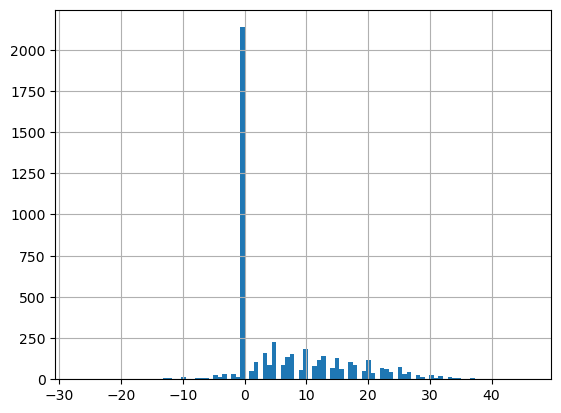

In [57]:
patient_progress.CMO_before_차이.hist(bins=100)

In [77]:
len(patient_progress.query("CMO_before_차이 == 0"))
len(patient_progress)

5132

In [38]:
df[[ 'Cap.pal_Pain_Intensity',
 'M.pal_Pain_Intensity',
 'Occlusion_lt_number',
 'Occlusion_rt_number',
 'Tongue_ridging_Intensity',
 'Mucosal_ridging_Intensity',
 'Rt_before',
 'Rt_after',
 'Lt_before',
 'Lt_after',]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28162 entries, 0 to 28161
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Cap.pal_Pain_Intensity     28162 non-null  int64 
 1   M.pal_Pain_Intensity       28162 non-null  int64 
 2   Occlusion_lt_number        28162 non-null  int64 
 3   Occlusion_rt_number        28162 non-null  int64 
 4   Tongue_ridging_Intensity   28162 non-null  int64 
 5   Mucosal_ridging_Intensity  28162 non-null  int64 
 6   Rt_before                  21359 non-null  object
 7   Rt_after                   21831 non-null  object
 8   Lt_before                  21359 non-null  object
 9   Lt_after                   21831 non-null  object
dtypes: int64(6), object(4)
memory usage: 2.1+ MB


### 모델

#### 임베딩을 위한 맥락 부여

In [11]:
import pandas as pd
import openai
import numpy as np

def create_contextual_text(row):
    """
    환자 데이터를 임상적 맥락을 강화한 방식으로 구조화하여 텍스트 생성
    """
    # 안전하게 열 접근하는 헬퍼 함수
    def safe_access(row, key):
        if isinstance(row, dict):
            return row.get(key, None)
        else:
            try:
                return row[key] if key in row.index else None
            except:
                return None
    
    # 값 유효성 확인 헬퍼 함수
    def is_valid(value):
        return pd.notna(value) and value is not None
    
    # 최종 임상 텍스트를 담을 섹션별 컨테이너
    clinical_sections = []
    
    # 1. 주호소 및 증상 섹션 (Core Symptoms)
    symptoms_context = []
    
    # 증상 위치와 종류 통합
    cc_location = safe_access(row, 'CC_location')
    cc_pain_type = safe_access(row, 'CC_pain_type')
    
    if is_valid(cc_location) and is_valid(cc_pain_type):
        symptoms_context.append(f"주호소: 환자는 {cc_location}에 {cc_pain_type}을 호소합니다.")
    elif is_valid(cc_location):
        symptoms_context.append(f"주호소 위치: {cc_location}")
    elif is_valid(cc_pain_type):
        symptoms_context.append(f"통증 유형: {cc_pain_type}")
    
    # 턱 관련 통증과 불편감 세부 정보 추가
    cc_painUncomp_desc_jaw = safe_access(row, 'CC_painUncomp_desc_jaw')
    if is_valid(cc_painUncomp_desc_jaw):
        symptoms_context.append(f"턱 관련 통증 및 불편감: {cc_painUncomp_desc_jaw}")
    
    # 기능적 제한 정보 추가
    cc_disable_desc_jaw = safe_access(row, 'CC_disable_desc_jaw')
    if is_valid(cc_disable_desc_jaw):
        symptoms_context.append(f"턱 기능 제한: {cc_disable_desc_jaw}")
    
    # 근육과 관절 관련 증상 추가
    cc_muscle_joint_desc_stress = safe_access(row, 'CC_muscle_joint_desc_stress')
    if is_valid(cc_muscle_joint_desc_stress):
        symptoms_context.append(f"근육 및 관절 상태: {cc_muscle_joint_desc_stress}")
    
    # 통증 강도와 지속 기간 정보
    cc_severity = safe_access(row, 'CC_severity')
    if is_valid(cc_severity):
        symptoms_context.append(f"통증 강도(1-5): {cc_severity}")
    
    cc_vas = safe_access(row, 'CC_vas')
    if is_valid(cc_vas):
        symptoms_context.append(f"VAS 통증 점수: {cc_vas}")
    
    cc_duration = safe_access(row, 'CC_duration')
    if is_valid(cc_duration):
        symptoms_context.append(f"증상 지속 기간: {cc_duration}")
    
    # 증상 섹션을 통합하여 전체 맥락에 추가
    if symptoms_context:
        clinical_sections.append("【증상 정보】\n" + "\n".join(symptoms_context))
    
    # 2. 병력 및 습관 섹션 (History & Habits)
    history_context = []
    
    # 치과 관련 과거력
    cc_dentalHistory_desc = safe_access(row, 'CC_dentalHistory_desc')
    if is_valid(cc_dentalHistory_desc):
        history_context.append(f"치과 병력: {cc_dentalHistory_desc}")
    
    # 클리닉 방문 이력
    cc_clinic_history_desc = safe_access(row, 'CC_clinic_history_desc')
    if is_valid(cc_clinic_history_desc):
        history_context.append(f"턱관절 관련 과거 치료: {cc_clinic_history_desc}")
    
    # 생활 습관 요인
    cc_factor_habbit = safe_access(row, 'CC_factor_habbit')
    if is_valid(cc_factor_habbit):
        history_context.append(f"생활 습관 요인: {cc_factor_habbit}")
    
    # 습관 관련 상세 정보
    habit_details = []
    
    habit_type = safe_access(row, '습관_habit_type')
    if is_valid(habit_type):
        habit_details.append(f"습관 유형: {habit_type}")
    
    habit_frequency = safe_access(row, '습관_frequency')
    if is_valid(habit_frequency):
        habit_details.append(f"습관 빈도: {habit_frequency}")
    
    habit_awareness = safe_access(row, '습관_awareness')
    if is_valid(habit_awareness):
        habit_details.append(f"습관 인지 여부: {habit_awareness}")
    
    habit_improvement = safe_access(row, '습관_improvement')
    if is_valid(habit_improvement):
        habit_details.append(f"습관 개선 상태: {habit_improvement}")
    
    if habit_details:
        history_context.append("습관 상세정보: " + ", ".join(habit_details))
    
    # 병력 및 습관 섹션을 통합하여 전체 맥락에 추가
    if history_context:
        clinical_sections.append("【병력 및 습관】\n" + "\n".join(history_context))
    
    # 3. 치료 관련 섹션 (Treatment)
    treatment_context = []
    
    # 치료 계획
    cc_treat_plan = safe_access(row, 'CC_treat_plan')
    if is_valid(cc_treat_plan):
        treatment_context.append(f"치료 계획: {cc_treat_plan}")
    
    # 약물 관련 정보
    medication_details = []
    
    medication_type = safe_access(row, '약_medication_type')
    if is_valid(medication_type):
        medication_details.append(f"약물 유형: {medication_type}")
    
    medication_frequency = safe_access(row, '약_frequency')
    if is_valid(medication_frequency):
        medication_details.append(f"복용 빈도: {medication_frequency}")
    
    medication_duration = safe_access(row, '약_duration')
    if is_valid(medication_duration):
        medication_details.append(f"복용 기간: {medication_duration}")
    
    medication_compliance = safe_access(row, '약_compliance')
    if is_valid(medication_compliance):
        medication_details.append(f"복약 순응도: {medication_compliance}")
    
    if medication_details:
        treatment_context.append("약물 정보: " + ", ".join(medication_details))
    
    # 장치 관련 정보
    device_details = []
    
    device_type = safe_access(row, '장치_device_type')
    if is_valid(device_type):
        device_details.append(f"장치 유형: {device_type}")
    
    device_usage_pattern = safe_access(row, '장치_usage_pattern')
    if is_valid(device_usage_pattern):
        device_details.append(f"사용 패턴: {device_usage_pattern}")
    
    device_duration = safe_access(row, '장치_duration')
    if is_valid(device_duration):
        device_details.append(f"사용 기간: {device_duration}")
    
    device_compliance = safe_access(row, '장치_compliance')
    if is_valid(device_compliance):
        device_details.append(f"장치 순응도: {device_compliance}")
    
    if device_details:
        treatment_context.append("장치 정보: " + ", ".join(device_details))
    
    # 찜질/마사지 정보
    therapy_details = []
    
    # 찜질 정보
    hot_pack_info = []
    hot_pack_status = safe_access(row, '찜질_status')
    
    if is_valid(hot_pack_status) and hot_pack_status == 1:
        hot_pack_info.append("찜질 시행")
        
        hot_pack_frequency = safe_access(row, '찜질_frequency')
        if is_valid(hot_pack_frequency):
            hot_pack_info.append(f"빈도: {hot_pack_frequency}")
        
        hot_pack_duration = safe_access(row, '찜질_duration')
        if is_valid(hot_pack_duration):
            hot_pack_info.append(f"시간: {hot_pack_duration}분")
        
        hot_pack_method = safe_access(row, '찜질_method')
        if is_valid(hot_pack_method):
            hot_pack_info.append(f"방법: {hot_pack_method}")
    
    if hot_pack_info:
        therapy_details.append("찜질: " + ", ".join(hot_pack_info))
    
    # 마사지/스트레칭 정보
    massage_info = []
    
    massage_type = safe_access(row, '마사지, 스트레칭_type')
    if is_valid(massage_type):
        massage_info.append(f"유형: {massage_type}")
        
        massage_frequency = safe_access(row, '마사지, 스트레칭_frequency')
        if is_valid(massage_frequency):
            massage_info.append(f"빈도: {massage_frequency}")
        
        massage_duration = safe_access(row, '마사지, 스트레칭_duration')
        if is_valid(massage_duration):
            massage_info.append(f"시간: {massage_duration}분")
        
        massage_method = safe_access(row, '마사지, 스트레칭_method')
        if is_valid(massage_method):
            massage_info.append(f"방법: {massage_method}")
    
    if massage_info:
        therapy_details.append("마사지/스트레칭: " + ", ".join(massage_info))
    
    if therapy_details:
        treatment_context.append("치료 요법: " + "; ".join(therapy_details))
    
    # 치료 섹션을 통합하여 전체 맥락에 추가
    if treatment_context:
        clinical_sections.append("【치료 정보】\n" + "\n".join(treatment_context))
    
    # 4. 임상 측정 데이터 섹션 (Clinical Measurements)
    measurements_context = []
    
    # 입 벌림 관련 측정값
    opening_measurements = []
    
    cmo_before = safe_access(row, 'CMO_before')
    if is_valid(cmo_before):
        opening_measurements.append(f"편안한 개구량(처음): {cmo_before}mm")
    
    cmo_after = safe_access(row, 'CMO_after')
    if is_valid(cmo_after):
        opening_measurements.append(f"편안한 개구량(이후): {cmo_after}mm")
    
    mmo_before = safe_access(row, 'MMO_before')
    if is_valid(mmo_before):
        opening_measurements.append(f"최대 개구량(처음): {mmo_before}mm")
    
    mmo_after = safe_access(row, 'MMO_after')
    if is_valid(mmo_after):
        opening_measurements.append(f"최대 개구량(이후): {mmo_after}mm")
    
    if opening_measurements:
        measurements_context.append("개구량 측정: " + ", ".join(opening_measurements))
    
    # 턱 편위 관련 정보
    deviation_info = []
    
    deviation_pattern = safe_access(row, 'deviation_pattern_type')
    if is_valid(deviation_pattern):
        deviation_info.append(f"편위 패턴: {deviation_pattern}")
    
    deviation_direction = safe_access(row, 'deviation_direction')
    if is_valid(deviation_direction):
        deviation_info.append(f"편위 방향: {deviation_direction}")
    
    deviation_intensity = safe_access(row, 'deviation_intensity')
    if is_valid(deviation_intensity):
        deviation_info.append(f"편위 강도: {deviation_intensity}")
    
    if deviation_info:
        measurements_context.append("턱 편위: " + ", ".join(deviation_info))
    
    # 턱관절 통증 관련 정보
    pain_info = []
    
    # 촉진 시 통증
    cap_pain_intensity = safe_access(row, 'Cap.pal_Pain_Intensity')
    if is_valid(cap_pain_intensity):
        cap_pain_direction = safe_access(row, 'Cap.pal_Pain_Direction')
        cap_pain_situation = safe_access(row, 'Cap.pal_Pain_Situation')
        
        cap_pain_text = f"촉진 시 통증 강도: {cap_pain_intensity}"
        if is_valid(cap_pain_direction):
            cap_pain_text += f", 방향: {cap_pain_direction}"
        if is_valid(cap_pain_situation):
            cap_pain_text += f", 상황: {cap_pain_situation}"
        
        pain_info.append(cap_pain_text)
    
    # 운동 시 통증
    m_pain_intensity = safe_access(row, 'M.pal_Pain_Intensity')
    if is_valid(m_pain_intensity):
        m_pain_direction = safe_access(row, 'M.pal_Pain_Direction')
        m_pain_situation = safe_access(row, 'M.pal_Pain_Situation')
        
        m_pain_text = f"운동 시 통증 강도: {m_pain_intensity}"
        if is_valid(m_pain_direction):
            m_pain_text += f", 방향: {m_pain_direction}"
        if is_valid(m_pain_situation):
            m_pain_text += f", 상황: {m_pain_situation}"
        
        pain_info.append(m_pain_text)
    
    if pain_info:
        measurements_context.append("턱관절 통증: " + ", ".join(pain_info))
    
    # 턱관절 소리 관련 정보
    noise_info = []
    
    noise_code = safe_access(row, 'Noise_Code')
    if is_valid(noise_code) and noise_code != 'No-Noise':
        noise_info.append(f"소리 유형: {noise_code}")
        
        noise_direction = safe_access(row, 'Noise_Direction')
        if is_valid(noise_direction):
            noise_info.append(f"방향: {noise_direction}")
        
        noise_intensity = safe_access(row, 'Noise_Intensity')
        if is_valid(noise_intensity):
            noise_info.append(f"강도: {noise_intensity}")
        
        noise_situation = safe_access(row, 'Noise_Situation')
        if is_valid(noise_situation):
            noise_info.append(f"발생 상황: {noise_situation}")
    
    if noise_info:
        measurements_context.append("턱관절 소리: " + ", ".join(noise_info))
    
    # 교합 관련 정보
    occlusion_info = []
    
    occlusion_lt_number = safe_access(row, 'Occlusion_lt_number')
    occlusion_rt_number = safe_access(row, 'Occlusion_rt_number')
    occlusion_lt_intensity = safe_access(row, 'Occlusion_lt_Intensity')
    occlusion_rt_intensity = safe_access(row, 'Occlusion_rt_Intensity')
    
    if is_valid(occlusion_lt_number) or is_valid(occlusion_rt_number):
        lt_info = f"왼쪽 교합 치아 수: {occlusion_lt_number if is_valid(occlusion_lt_number) else '정보 없음'}"
        rt_info = f"오른쪽 교합 치아 수: {occlusion_rt_number if is_valid(occlusion_rt_number) else '정보 없음'}"
        
        lt_intensity = f"왼쪽 교합 강도: {occlusion_lt_intensity if is_valid(occlusion_lt_intensity) else '정보 없음'}"
        rt_intensity = f"오른쪽 교합 강도: {occlusion_rt_intensity if is_valid(occlusion_rt_intensity) else '정보 없음'}"
        
        occlusion_info.extend([lt_info, rt_info, lt_intensity, rt_intensity])
    
    oj_value = safe_access(row, 'oj')
    if is_valid(oj_value):
        occlusion_info.append(f"수평피개량: {oj_value}mm")
    
    ob_value = safe_access(row, 'ob')
    if is_valid(ob_value):
        occlusion_info.append(f"수직피개량: {ob_value}mm")
    
    # 정중선 편위 정보
    midline_shift_jaw = safe_access(row, 'Midline_Shift_Jaw')
    if is_valid(midline_shift_jaw):
        midline_info = f"정중선 편위 턱: {midline_shift_jaw}"
        
        midline_dir_x = safe_access(row, 'Midline_Shift_Direction_x')
        if is_valid(midline_dir_x):
            midline_info += f", X축 방향: {midline_dir_x}"
        
        midline_dir_y = safe_access(row, 'Midline_Shift_Direction_y')
        if is_valid(midline_dir_y):
            midline_info += f", Y축 방향: {midline_dir_y}"
        
        midline_amount = safe_access(row, 'Midline_Shift_Amount')
        if is_valid(midline_amount):
            midline_info += f", 편위량: {midline_amount}mm"
        
        occlusion_info.append(midline_info)
    
    # CR-CO 관련 정보
    crco_dir_x = safe_access(row, 'CRCO_Direction_x')
    if is_valid(crco_dir_x):
        crco_info = f"CRCO X축 방향: {crco_dir_x}"
        
        crco_dir_y = safe_access(row, 'CRCO_Direction_y')
        if is_valid(crco_dir_y):
            crco_info += f", Y축 방향: {crco_dir_y}"
        
        crco_amount = safe_access(row, 'CRCO_Amount')
        if is_valid(crco_amount):
            crco_info += f", 양: {crco_amount}"
        
        occlusion_info.append(crco_info)
    
    # 혀 압흔 정보
    tongue_ridging = safe_access(row, 'Tongue_ridging_Intensity')
    if is_valid(tongue_ridging):
        occlusion_info.append(f"혀 압흔 강도: {tongue_ridging}")
    
    # 우측 및 좌측 측방 이동량
    rt_before = safe_access(row, 'Rt_before')
    rt_after = safe_access(row, 'Rt_after')
    lt_before = safe_access(row, 'Lt_before')
    lt_after = safe_access(row, 'Lt_after')
    
    lateral_movement_info = []
    if is_valid(rt_before):
        lateral_movement_info.append(f"우측 측방 이동량(처음): {rt_before}mm")
    if is_valid(rt_after):
        lateral_movement_info.append(f"우측 측방 이동량(이후): {rt_after}mm")
    if is_valid(lt_before):
        lateral_movement_info.append(f"좌측 측방 이동량(처음): {lt_before}mm")
    if is_valid(lt_after):
        lateral_movement_info.append(f"좌측 측방 이동량(이후): {lt_after}mm")
    
    if lateral_movement_info:
        occlusion_info.extend(lateral_movement_info)
    
    if occlusion_info:
        measurements_context.append("교합 및 턱 운동 상태: " + ", ".join(occlusion_info))
    
    # 임상 측정값 섹션을 통합하여 전체 맥락에 추가
    if measurements_context:
        clinical_sections.append("【임상 측정 데이터】\n" + "\n".join(measurements_context))
    
    # 5. 결과/치료 효과 섹션 (Outcomes)
    outcomes_context = []
    
    # 치료 효과 관련 정보
    next_visit_days = safe_access(row, 'Next_Visit_Days')
    if is_valid(next_visit_days):
        outcomes_context.append(f"다음 방문 예정일: {next_visit_days}일 후")
    
    # VAS 점수 변화 (이 부분은 위의 CC_vas와 중복될 수 있지만, 결과 섹션에도 포함)
    cc_vas_outcome = safe_access(row, 'CC_vas')
    if is_valid(cc_vas_outcome):
        outcomes_context.append(f"현재 통증 점수(VAS): {cc_vas_outcome}")
    
    # 결과 섹션을 통합하여 전체 맥락에 추가
    if outcomes_context:
        clinical_sections.append("【치료 결과】\n" + "\n".join(outcomes_context))
    
    # 모든 섹션을 통합하여 하나의 맥락화된 텍스트 생성
    contextual_text = "\n\n".join(clinical_sections)
    
    # 환자 ID와 날짜 정보를 헤더로 추가
    patient_id = safe_access(row, '환자번호')
    visit_date = safe_access(row, '날짜')
    
    header = f"환자번호: {patient_id if is_valid(patient_id) else '정보 없음'}, 방문일: {visit_date if is_valid(visit_date) else '정보 없음'}"
    
    # 최종 맥락화된 텍스트
    final_text = f"{header}\n\n{contextual_text}"
    
    return final_text

def enhance_clinical_relationships(row): #-> 너무 뇌피셜임. 일단 누락.
    """임상적으로 관련된 필드들 간의 관계를 강화"""
    relationships = []
    
    # 증상과 치료의 관계
    if pd.notna(row['CC_pain_type']) and pd.notna(row['CC_treat_plan']):
        relationships.append(f"{row['CC_pain_type']}에 대한 치료 계획: {row['CC_treat_plan']}")
    
    # 습관과 증상의 관계
    if pd.notna(row['습관_habit_type']) and pd.notna(row['CC_muscle_joint_desc_stress']):
        relationships.append(f"습관 '{row['습관_habit_type']}'과 근육 상태 '{row['CC_muscle_joint_desc_stress']}'의 연관성")
    
    # 치료와 결과의 관계
    if pd.notna(row['장치_device_type']) and pd.notna(row['CC_vas']):
        relationships.append(f"{row['장치_device_type']} 장치 사용 후 통증 점수: {row['CC_vas']}")
    
    return relationships

def identify_patient_patterns(row):
    """환자 데이터에서 중요 패턴 식별"""
    patterns = []
    
    # 통증 위치와 종류 패턴
    if pd.notna(row['CC_location']) and pd.notna(row['CC_pain_type']):
        patterns.append(f"패턴-위치통증: {row['CC_location']}_{row['CC_pain_type']}")
    
    # 개구량 변화 패턴
    if pd.notna(row['MMO_before']) and pd.notna(row['MMO_after']):
        try:
            change = float(row['MMO_after']) - float(row['MMO_before'])
            if change > 3:
                patterns.append("패턴-개구량: 뚜렷한_개선")
            elif change > 0:
                patterns.append("패턴-개구량: 경미한_개선")
            elif change < -3:
                patterns.append("패턴-개구량: 악화")
            else:
                patterns.append("패턴-개구량: 유지")
        except:
            pass
    
    # 습관과 순응도 패턴
    if pd.notna(row['습관_awareness']) and pd.notna(row['장치_compliance']):
        patterns.append(f"패턴-순응도: 습관인지_{row['습관_awareness']}_장치순응도_{row['장치_compliance']}")
    
    return patterns

def apply_section_weights(text, section_weights):
    """섹션별 가중치를 적용한 텍스트 생성 - 특수 마커 사용"""
    sections = text.split("\n\n")
    weighted_sections = []
    
    for section in sections:
        for key, weight in section_weights.items():
            if key in section:
                # 섹션 시작 부분에 가중치 마커 추가
                weighted_section = f"<WEIGHT={weight}> {section}"
                weighted_sections.append(weighted_section)
                break
        else:
            weighted_sections.append(section)
    
    return "\n\n".join(weighted_sections)


In [12]:
# OpenAI API v1.0.0+ 호환 함수
def create_hybrid_contextual_embedding(df, api_key):
    """환자 데이터의 하이브리드 맥락 임베딩 생성"""
    
    # OpenAI 클라이언트 초기화 (v1.0.0 이상)
    from openai import OpenAI
    client = OpenAI(api_key=api_key)
    
    # 임베딩 저장할 리스트
    embeddings = []

    section_weights = {
        "【증상 정보】": 2,  # 증상 정보는 2배 중요
        "【치료 결과】": 2,  # 치료 결과도 2배 중요
        "【병력 및 습관】": 1.5  # 병력 및 습관은 1.5배 중요
    }
    
    for index, row in df.iterrows():
        # 1. 맥락화된 텍스트 생성
        row_dict = row.to_dict()
        clinical_text = create_contextual_text(row_dict)
        
        # 2. 임상적 관계 강화
        relationships = enhance_clinical_relationships(row_dict)
        if relationships:
            clinical_text += "\n\n【임상적 관계】\n" + "\n".join(relationships)
        
        # 3. 환자 패턴 식별 및 추가
        patterns = identify_patient_patterns(row_dict)
        if patterns:
            clinical_text += "\n\n【패턴 정보】\n" + "\n".join(patterns)
        
        # 4. 섹션 가중치 적용
        weighted_text = apply_section_weights(clinical_text, section_weights)
        
        # 맥락화된 텍스트 출력 (테스트용)
        print(f"환자 {row_dict.get('환자번호', 'unknown')}의 맥락화된 텍스트 샘플:\n{weighted_text[:500]}...\n")
        
        # 5. 임베딩 생성 - OpenAI API 호출 (v1.0.0 이상)
        try:
            response = client.embeddings.create(
                model="text-embedding-ada-002",
                input=weighted_text
            )
            # 새로운 API에서는 response 구조가 다름
            embedding = response.data[0].embedding
            
            # 결과 저장
            embeddings.append({
                'patient_id': row_dict.get('환자번호', 'unknown'),
                'visit_date': row_dict.get('날짜', 'unknown'),
                'embedding': embedding,
                'vas': row_dict.get('CC_vas', None) if pd.notna(row_dict.get('CC_vas', None)) else None
            })
            
            print(f"환자 {row_dict.get('환자번호', 'unknown')}의 임베딩 생성 완료 (차원: {len(embedding)})")
            
        except Exception as e:
            print(f"환자 {row_dict.get('환자번호', 'unknown')}의 임베딩 생성 중 오류 발생: {str(e)}")
    
    return embeddings



In [ ]:
# 메인 함수 - OpenAI API v1.0.0+ 호환
# 메인 함수 - OpenAI API v1.0.0+ 호환
import json
import pandas as pd
import numpy as np
from tqdm import tqdm
import os

def main():
    # 적은 수의 샘플만 테스트 (전체 데이터셋을 처리하려면 이 부분 주석 처리)
    df_sample = df
    
    print(f"총 {len(df_sample)}개의 환자 데이터에 대해 임베딩을 생성합니다...")
    
    # 배치 크기 설정
    batch_size = 2000
    total_rows = len(df_sample)
    
    # 배치 단위로 처리
    for i in tqdm(range(0, total_rows, batch_size), desc="배치 처리 중"):
        # 현재 배치의 끝 인덱스 계산
        end_idx = min(i + batch_size, total_rows)
        
        # 현재 배치 추출
        batch_df = df_sample.iloc[i:end_idx]
        
        # 임베딩 생성
        batch_embeddings = create_hybrid_contextual_embedding(batch_df, api_key)
        
        # 배치별 파일명 설정
        batch_filename = f'patient_embeddings_batch_{i//batch_size+1}.json'
        
        # 임베딩 저장
        save_embeddings_to_json(batch_embeddings, batch_filename)
        
        print(f"배치 {i//batch_size+1}: {len(batch_embeddings)}개 환자 데이터의 임베딩이 '{batch_filename}'에 저장되었습니다.")
    
    print(f"총 {total_rows}개 환자 데이터의 임베딩이 생성되어 {(total_rows-1)//batch_size+1}개의 배치 파일로 저장되었습니다.")
    
    # 첫 번째 배치 파일에서 임베딩 차원 정보 읽기
    try:
        with open(f'patient_embeddings_batch_1.json', 'r', encoding='utf-8') as f:
            first_batch = json.load(f)
            if first_batch:
                print("임베딩 차원:", len(first_batch[0]['embedding']) if 'embedding' in first_batch[0] else "없음")
    except Exception as e:
        print(f"임베딩 차원 정보를 읽는 중 오류 발생: {e}")

def save_embeddings_to_json(embeddings, filename):
    """임베딩을 JSON 파일로 저장하는 함수"""
    # JSON 직렬화를 위해 NumPy 배열과 Timestamp 객체 처리
    serializable_embeddings = []
    for item in embeddings:
        serializable_item = item.copy()
        
        # 임베딩 벡터가 NumPy 배열인 경우 리스트로 변환
        if 'embedding' in serializable_item and hasattr(serializable_item['embedding'], 'tolist'):
            serializable_item['embedding'] = serializable_item['embedding'].tolist()
        
        # Timestamp 객체가 있는 경우 문자열로 변환
        if 'visit_date' in serializable_item and hasattr(serializable_item['visit_date'], 'strftime'):
            serializable_item['visit_date'] = serializable_item['visit_date'].strftime('%Y-%m-%d')
        
        serializable_embeddings.append(serializable_item)
    
    # 커스텀 JSON 인코더 사용
    class CustomJSONEncoder(json.JSONEncoder):
        def default(self, obj):
            # pandas Timestamp 객체 처리
            if hasattr(obj, 'strftime'):
                return obj.strftime('%Y-%m-%d')
            # NumPy 배열 처리
            if hasattr(obj, 'tolist'):
                return obj.tolist()
            return super().default(obj)
    
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(serializable_embeddings, f, cls=CustomJSONEncoder, ensure_ascii=False, indent=2)

# 함수 실행
if __name__ == "__main__":
    main()

In [28]:
df.columns

Index(['환자번호', '날짜', 'CC', '약', '장치', '습관', '찜질', '마사지, 스트레칭', 'PI', 'CMO',
       'MMO', 'Cap.pal', 'M.pal', 'Noise', 'Loading', 'Occlusion', 'OJ/OB',
       'Class', 'Midline Shift', 'Deviation', 'CR-CO', 'Tongue ridging',
       'Mucosal ridging', 'Ultrasono', 'Rt', 'Lt', '치료계획', 'End feel',
       'CC_location', 'CC_pain_type', 'CC_painUncomp_desc_jaw',
       'CC_disable_desc_jaw', 'CC_muscle_joint_desc_stress',
       'CC_dentalHistory_desc', 'CC_clinic_history_desc', 'CC_factor_habbit',
       'CC_treat_plan', 'CC_severity', 'CC_duration', '약_medication_type',
       '약_frequency', '약_duration', '약_compliance', '장치_device_type',
       '장치_usage_pattern', '장치_duration', '장치_compliance', '습관_habit_type',
       '습관_frequency', '습관_awareness', '습관_improvement', '찜질_status',
       '찜질_frequency', '찜질_duration', '찜질_method', '마사지, 스트레칭_type',
       '마사지, 스트레칭_frequency', '마사지, 스트레칭_duration', '마사지, 스트레칭_method',
       'CMO_before', 'CMO_after', 'MMO_before', 'MMO_after',
       '